In [6]:
from __future__ import annotations

import csv
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import cv2
import numpy as np

In [7]:
@dataclass
class BBox:
    x: float
    y: float
    width: float
    height: float

    def as_int_tuple(self):
        return (
            int(round(self.x)),
            int(round(self.y)),
            int(round(self.width)),
            int(round(self.height)),
        )

    @property
    def center(self):
        return np.array(
            [self.x + self.width * 0.5,
             self.y + self.height * 0.5],
            dtype=np.float32
        )

    def with_center(self, center):
        return BBox(
            float(center[0] - self.width * 0.5),
            float(center[1] - self.height * 0.5),
            self.width,
            self.height,
        )

    def clip(self, frame_shape):
        h, w = frame_shape[:2]

        width = max(1.0, min(float(self.width), float(w)))
        height = max(1.0, min(float(self.height), float(h)))

        x = min(max(0.0, float(self.x)), float(w) - width)
        y = min(max(0.0, float(self.y)), float(h) - height)

        return BBox(x, y, width, height)

    def to_dict(self):
        return {
            "x": self.x,
            "y": self.y,
            "width": self.width,
            "height": self.height
        }


@dataclass
class TrackerEstimate:
    bbox: BBox
    confidence: float
    source: str


@dataclass
class TrackingOutput:
    frame_index: int
    bbox: BBox
    tracker_confidence: float
    motion_confidence: float
    trusted_source: str

    def to_dict(self):
        return {
            "frame_index": self.frame_index,
            "bbox": self.bbox.to_dict(),
            "tracker_confidence": round(float(self.tracker_confidence), 4),
            "motion_model_confidence": round(float(self.motion_confidence), 4),
            "trusted_output_source": self.trusted_source,
        }

In [8]:
class ConstantVelocityModel:

    def __init__(self, initial_bbox):
        self._bbox = initial_bbox
        self._velocity = np.zeros(2, dtype=np.float32)
        self._misses = 0
        self._initialized = False

    def predict(self, frame_shape):

        predicted = self._bbox.with_center(
            self._bbox.center + self._velocity
        ).clip(frame_shape)

        self._bbox = predicted

        confidence = max(
            0.05,
            0.88 * (0.72 ** self._misses)
        )

        return TrackerEstimate(
            predicted,
            confidence,
            "motion_model"
        )

    def correct(self, bbox, measurement_confidence, accepted_tracker_update):

        previous_center = self._bbox.center
        current_center = bbox.center

        if self._initialized:

            measured_velocity = (
                current_center - previous_center
            )

            alpha = min(
                max(measurement_confidence, 0.0),
                1.0
            ) * 0.65

            self._velocity = (
                (1.0 - alpha) * self._velocity
                + alpha * measured_velocity
            )
        else:
            self._initialized = True

        self._bbox = bbox
        self._misses = (
            0 if accepted_tracker_update
            else self._misses + 1
        )

In [9]:
class GpuTemplateTracker:

    def __init__(
        self,
        first_frame,
        initial_bbox,
        search_scale=4.5,
        template_update_rate=0.02,
    ):

        self.search_scale = max(
            1.2,
            float(search_scale)
        )

        self.template_update_rate = min(
            max(template_update_rate, 0.0),
            0.5,
        )

        self.template_bbox = initial_bbox.clip(
            first_frame.shape
        )

        self.template = self._crop_gray(
            first_frame,
            self.template_bbox
        )
        cv2.imwrite(
            "template_debug.jpg",
             self.template

)

        self.uses_cuda = self._cuda_available()
        self._cuda_matcher = None

        if self.uses_cuda:
            self._cuda_matcher = cv2.cuda.createTemplateMatching(
                cv2.CV_8UC1,
                cv2.TM_CCORR_NORMED
            )

    def locate(self, frame, predicted_bbox):

        search_box = self._search_box(
            predicted_bbox,
            frame.shape
        )

        search_gray = self._crop_gray(
            frame,
            search_box
        )

        if (
            search_gray.shape[0] < self.template.shape[0]
            or
            search_gray.shape[1] < self.template.shape[1]
        ):
            return TrackerEstimate(
                predicted_bbox.clip(frame.shape),
                0.0,
                "object_tracker",
            )

        _, max_val, _, max_loc = self._match(search_gray)

        confidence = float(
            np.clip(max_val, 0.0, 1.0)
        )

        bbox = BBox(
            search_box.x + float(max_loc[0]),
            search_box.y + float(max_loc[1]),
            self.template_bbox.width,
            self.template_bbox.height,
        ).clip(frame.shape)

        return TrackerEstimate(
            bbox,
            confidence,
            "object_tracker",
        )

    def update_template(self, frame, bbox):

        new_template = self._crop_gray(
            frame,
            bbox.clip(frame.shape)
        )

        if new_template.shape != self.template.shape:
            new_template = cv2.resize(
                new_template,
                (
                    self.template.shape[1],
                    self.template.shape[0],
                ),
            )

        self.template = cv2.addWeighted(
            self.template,
            1.0 - self.template_update_rate,
            new_template,
            self.template_update_rate,
            0.0,
        )

    def _match(self, search_gray):

        if self.uses_cuda and self._cuda_matcher:

            gpu_search = cv2.cuda_GpuMat()
            gpu_template = cv2.cuda_GpuMat()

            gpu_search.upload(search_gray)
            gpu_template.upload(self.template)

            gpu_result = self._cuda_matcher.match(
                gpu_search,
                gpu_template
            )

            result = gpu_result.download()

        else:
            result = cv2.matchTemplate(
                search_gray,
                self.template,
                cv2.TM_CCOEFF_NORMED
            )

        return cv2.minMaxLoc(result)

    def _search_box(self, predicted_bbox, frame_shape):

        center = predicted_bbox.center

        width = predicted_bbox.width * self.search_scale
        height = predicted_bbox.height * self.search_scale

        return BBox(
            center[0] - width * 0.5,
            center[1] - height * 0.5,
            width,
            height,
        ).clip(frame_shape)

    @staticmethod
    def _crop_gray(frame, bbox):

        x, y, w, h = bbox.as_int_tuple()

        crop = frame[y:y+h, x:x+w]

        if crop.ndim == 3:
            crop = cv2.cvtColor(
                crop,
                cv2.COLOR_BGR2GRAY
            )

        return cv2.GaussianBlur(
            crop,
            (3,3),
            0
        )
        edges = cv2.Canny(
            crop,
            50,
            150
    )

    @staticmethod
    def _cuda_available():
        try:
            return (
                hasattr(cv2, "cuda")
                and
                cv2.cuda.getCudaEnabledDeviceCount() > 0
            )
        except:
            return False

In [11]:
class HybridObjectTracker:

    def __init__(
        self,
        first_frame,
        initial_bbox,
        tracker_accept_threshold=0.65,
    ):

        self.object_tracker = GpuTemplateTracker(
            first_frame,
            initial_bbox
        )

        self.motion_model = ConstantVelocityModel(
            initial_bbox
        )

        self.tracker_accept_threshold = (
            tracker_accept_threshold
        )

    def update(self, frame_index, frame):

        motion = self.motion_model.predict(
            frame.shape
        )

        tracker = self.object_tracker.locate(
            frame,
            motion.bbox
        )

        use_tracker = (
            tracker.confidence
            >=
            self.tracker_accept_threshold
        )

        if use_tracker:

            fused_bbox = self._blend_boxes(
                tracker.bbox,
                motion.bbox,
                tracker.confidence,
            )

            trusted_source = "object_tracker"
            if tracker.confidence > 0.75:

              self.object_tracker.update_template(
                  frame,
                  fused_bbox
            )

        else:
            fused_bbox = motion.bbox
            trusted_source = "motion_model"

        self.motion_model.correct(
            fused_bbox,
            tracker.confidence,
            use_tracker
        )

        return TrackingOutput(
            frame_index,
            fused_bbox,
            tracker.confidence,
            motion.confidence,
            trusted_source,
        )

    @staticmethod
    def _blend_boxes(
        tracker_bbox,
        motion_bbox,
        tracker_confidence
    ):

        tracker_weight = float(
            np.clip(
                0.35 + 0.55 * tracker_confidence,
                0.35,
                0.9,
            )
        )

        motion_weight = 1.0 - tracker_weight

        return BBox(
            tracker_weight * tracker_bbox.x
            + motion_weight * motion_bbox.x,

            tracker_weight * tracker_bbox.y
            + motion_weight * motion_bbox.y,

            tracker_weight * tracker_bbox.width
            + motion_weight * motion_bbox.width,

            tracker_weight * tracker_bbox.height
            + motion_weight * motion_bbox.height,
        )

In [12]:
def iter_video_frames(video_path):

    capture = cv2.VideoCapture(str(video_path))

    frame_index = 0

    while True:
        ok, frame = capture.read()

        if not ok:
            break

        yield frame_index, frame, capture
        frame_index += 1

    capture.release()


def draw_output(frame, output):

    annotated = frame.copy()

    x, y, w, h = output.bbox.as_int_tuple()

    color = (
        (40,220,80)
        if output.trusted_source == "object_tracker"
        else
        (60,160,255)
    )

    cv2.rectangle(
        annotated,
        (x,y),
        (x+w,y+h),
        color,
        2
    )

    label = (
        f"{output.trusted_source} "
        f"T:{output.tracker_confidence:.2f} "
        f"M:{output.motion_confidence:.2f}"
    )

    cv2.putText(
        annotated,
        label,
        (x,max(20,y-8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        color,
        2
    )

    return annotated

In [39]:
from google.colab import files

uploaded = files.upload()

Saving cd4.1.mp4 to cd4.1.mp4


Frame shape: (1080, 1920, 3)


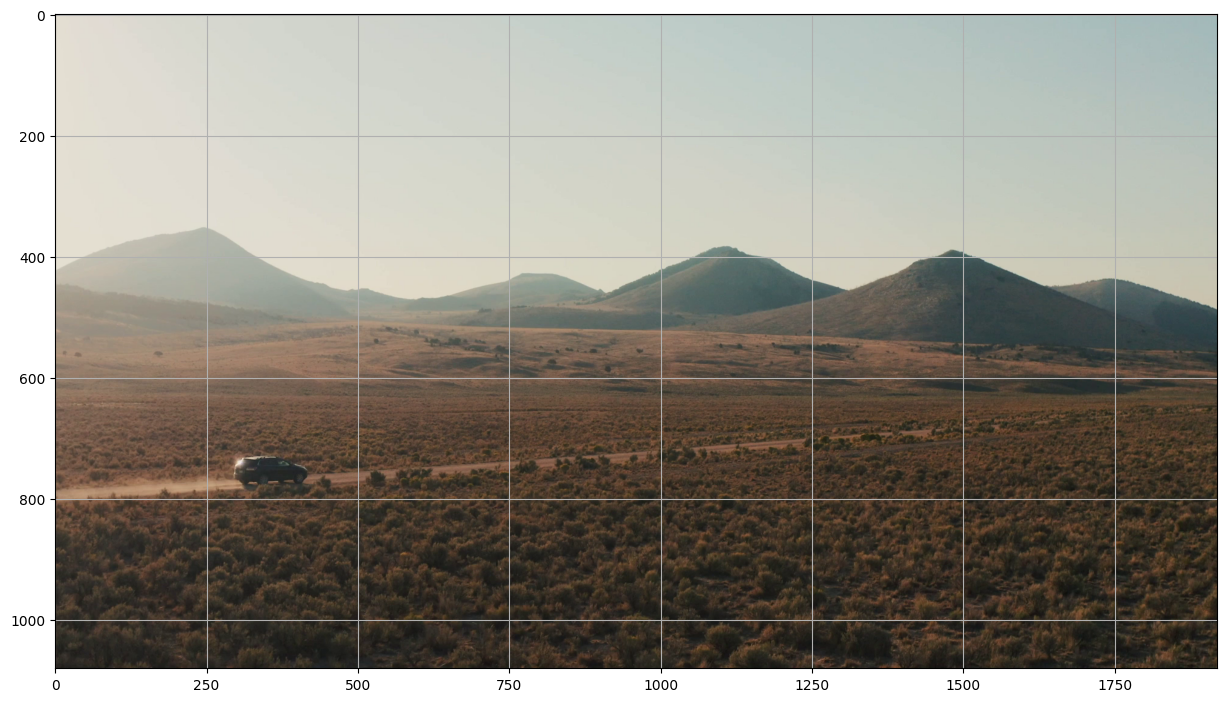

In [40]:
import cv2
import matplotlib.pyplot as plt

video_path = "/content/cd4.1.mp4"

cap = cv2.VideoCapture(video_path)

ret, first_frame = cap.read()

print("Frame shape:", first_frame.shape)

plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.grid()
plt.show()

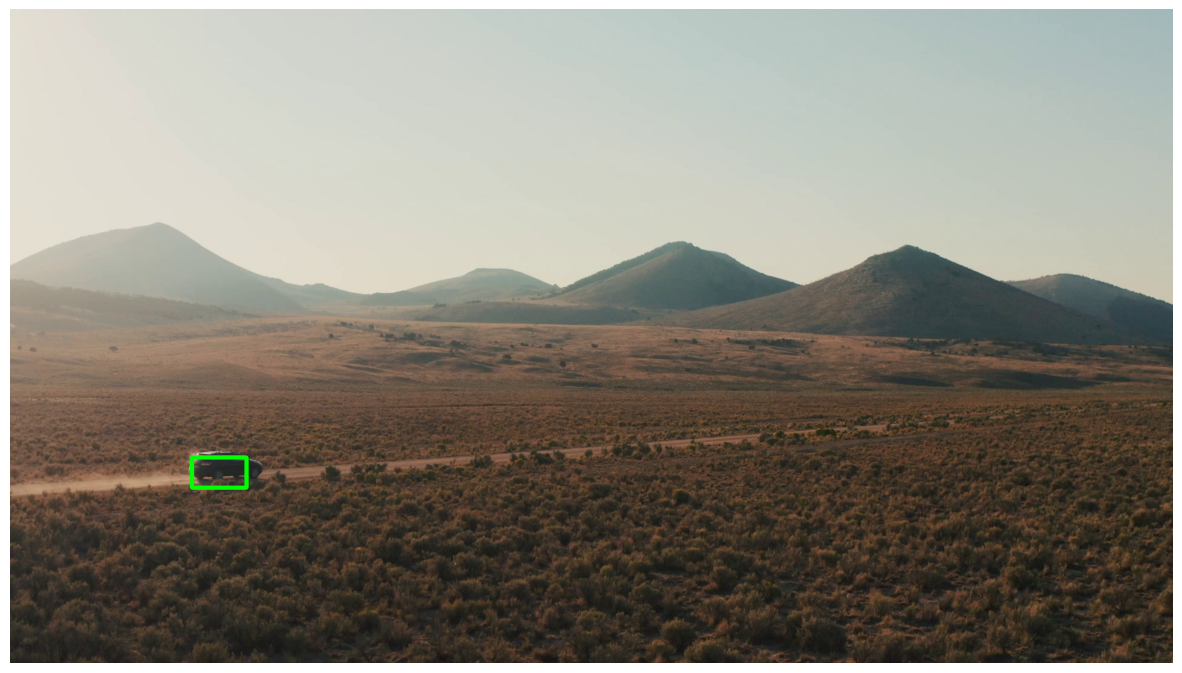

In [62]:
test = first_frame.copy()

initial_bbox = BBox(
    x = 300,
    y = 740,
    width = 90,
    height = 50
)

x, y, w, h = initial_bbox.as_int_tuple()

cv2.rectangle(
    test,
    (x, y),
    (x+w, y+h),
    (0,255,0),
    5
)

plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(test, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [60]:
video_path = "/content/cd4.1.mp4"

initial_bbox = BBox(
    x = 300,
    y = 740,
    width = 90,
    height = 50
)

frames = iter_video_frames(video_path)

first_index, first_frame, cap = next(frames)

tracker = HybridObjectTracker(
    first_frame,
    initial_bbox
)

outputs = []

In [63]:
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    "tracked_output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width,height)
)

for frame_index, frame, _ in frames:

    output = tracker.update(
        frame_index,
        frame
    )
    print(
      f"Frame={frame_index}",
      f"Source={output.trusted_source}",
      f"Tracker={output.tracker_confidence:.2f}",
      f"Motion={output.motion_confidence:.2f}",
      f"X={output.bbox.x:.0f}",
      f"Y={output.bbox.y:.0f}"
)

    outputs.append(output)

    annotated = draw_output(
        frame,
        output
    )

    writer.write(annotated)

writer.release()

print("Tracking complete")

Frame=1 Source=object_tracker Tracker=0.96 Motion=0.88 X=303 Y=740
Frame=2 Source=object_tracker Tracker=0.96 Motion=0.88 X=304 Y=739
Frame=3 Source=object_tracker Tracker=0.97 Motion=0.88 X=305 Y=739
Frame=4 Source=object_tracker Tracker=0.95 Motion=0.88 X=308 Y=738
Frame=5 Source=object_tracker Tracker=0.94 Motion=0.88 X=310 Y=738
Frame=6 Source=object_tracker Tracker=0.94 Motion=0.88 X=312 Y=738
Frame=7 Source=object_tracker Tracker=0.94 Motion=0.88 X=313 Y=738
Frame=8 Source=object_tracker Tracker=0.95 Motion=0.88 X=315 Y=737
Frame=9 Source=object_tracker Tracker=0.96 Motion=0.88 X=317 Y=737
Frame=10 Source=object_tracker Tracker=0.96 Motion=0.88 X=319 Y=736
Frame=11 Source=object_tracker Tracker=0.94 Motion=0.88 X=321 Y=736
Frame=12 Source=object_tracker Tracker=0.93 Motion=0.88 X=323 Y=735
Frame=13 Source=object_tracker Tracker=0.93 Motion=0.88 X=324 Y=735
Frame=14 Source=object_tracker Tracker=0.88 Motion=0.88 X=325 Y=735
Frame=15 Source=object_tracker Tracker=0.91 Motion=0.88 X

In [64]:
with open(
    "tracking_output.jsonl",
    "w"
) as f:

    for output in outputs:
        f.write(
            json.dumps(
                output.to_dict()
            ) + "\n"
        )

from google.colab import files

files.download("tracked_output.mp4")
files.download("tracking_output.jsonl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>